In [3]:
%load_ext Cython



The Cython extension is already loaded. To reload it, use:
  %reload_ext Cython


In [5]:
%%cython
cimport numpy as np
cpdef void NGP_xyz_prop(np.float32_t[:,:] pos, np.float32_t[:, :] prop, np.float32_t[:,:,:,:,:] gridM, float BoxSize):

    cdef int axis,dims,coord,nMmax,jM, coord_prop
    cdef long i,particles
    cdef float inv_cell_size
    cdef float pos0, pos1, pos2
    cdef int index[3]
    cdef int tobreak

    # find number of particles, the inverse of the cell size and dims
    particles = pos.shape[0];  coord = pos.shape[1];  dims = gridM.shape[0]; nMmax = gridM.shape[3]
    coord_prop = prop.shape[1]
    inv_cell_size = dims/BoxSize

    # when computing things in 2D, use the index[2]=0 plane
    for i in range(3):  index[i] = 0

    # do a loop over all particles
    for i in range(particles):
        for axis in range(coord):
            index[axis] = <int>(pos[i,axis]*inv_cell_size + 0.5)
            if axis == 0:
                pos0 = pos[i,axis] - index[axis]*BoxSize/dims
                
            if axis == 1:
                pos1 = pos[i,axis] - index[axis]*BoxSize/dims
                
            if axis == 2:
                pos2 = pos[i,axis] - index[axis]*BoxSize/dims
                
            index[axis] = (index[axis]+dims)%dims
        for jM in range(nMmax):
            if (gridM[index[0],index[1],index[2], jM, 0] == 0) and (gridM[index[0],index[1],index[2], jM, 1] == 0) and (gridM[index[0],index[1],index[2], jM, 2] == 0) and (gridM[index[0],index[1],index[2], jM, 3] == 0) and (gridM[index[0],index[1],index[2], jM, 4] == 0) and (gridM[index[0],index[1],index[2], jM, 5] == 0):
                gridM[index[0],index[1],index[2], jM, 0] = pos0
                gridM[index[0],index[1],index[2], jM, 1] = pos1
                gridM[index[0],index[1],index[2], jM, 2] = pos2
                for k in range(coord_prop):
                    gridM[index[0],index[1],index[2], jM, 3+k] = prop[i,k]
                break
            else:
                pass

In file included from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/ndarraytypes.h:1909:0,
                 from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from /u/spandey3/.cache/ipython/cython/_cython_magic_ee2cb8cae5330bb5e33db8d2ed4c6d8b.c:778:
/u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
 #warning "Using deprecated NumPy API, disable it with " \
  ^~~~~~~
/u/spandey3/.cache/ipython/cython/_cython_magic_ee2cb8cae5330bb5e33db8d2ed4c6d8b.c: In function ‘__pyx_pw_46_cython_magic_ee2cb8cae5330bb5e33db8d2ed4c6d8b_1NGP_xyz_prop’:
/u/spandey3/.cache/ipython/cython/_cython_magic_ee2cb8cae5330bb5e33db8d2

In [6]:
import numpy as np
import sys,os
import MAS_library as MASL
import pickle as pk
import h5py as h5
# from ngp_funcs import NGP_xyz_prop 
import skimage.measure as skmeasure
import ast

# add_space_token = bool(ast.literal_eval(sys.argv[-1]))

def mat_reshape(mat, grid1, grid2):
    '''
    Reshape input mat into (grid1, grid1, grid1, grid2, grid2, grid2) shape
    '''
    if len(mat.shape) == 3:
        mat_rs = np.reshape(mat, (grid1, grid2, grid1, grid2, grid1, grid2))
    else:
        mat_rs = np.reshape(mat, (grid1, grid2, grid1, grid2, grid1, grid2, *mat.shape[3:]))

    mat_rs = np.moveaxis(mat_rs, 1, 2)
    mat_rs = np.moveaxis(mat_rs, 4, 3)
    mat_rs = np.moveaxis(mat_rs, 3, 2)
    return mat_rs


def get_padded_mat(Npart, n_pad, grid_sbox, grid):
    Npart_pad = np.pad(Npart, n_pad, 'wrap')

    Npart_pad1 = np.zeros((grid, grid, grid, grid_sbox + 2*n_pad, grid_sbox + 2*n_pad, grid_sbox + 2*n_pad))
    fac = (grid_sbox + 2*n_pad)//grid_sbox    
    Npart_pad1_reduce = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox))    
    xstart, ystart, zstart = n_pad, n_pad, n_pad
    for jx in range(grid):
        for jy in range(grid):
            for jz in range(grid):
                Npart_pad1[jx, jy, jz] = Npart_pad[xstart + jx * grid_sbox - n_pad:xstart + (jx + 1) * grid_sbox + n_pad,
                                                        ystart + jy * grid_sbox - n_pad:ystart + (jy + 1) * grid_sbox + n_pad,
                                                        zstart + jz * grid_sbox - n_pad:zstart + (jz + 1) * grid_sbox + n_pad]

                Npart_pad1_reduce[jx, jy, jz] = skmeasure.block_reduce(Npart_pad1[jx, jy, jz], (fac, fac, fac), np.mean)
    return Npart_pad1_reduce, Npart_pad1






In [9]:
# def process_LH_sim(
isim = 0
isfid=False
LH_cosmo_val_file='/mnt/home/spandey/ceph/Quijote/latin_hypercube_params.txt'
import numpy as np
import sys,os
import MAS_library as MASL
import pickle as pk
import h5py as h5
# from ngp_funcs import NGP_xyz_prop 
import skimage.measure as skmeasure
import colossus  
from colossus.cosmology import cosmology
from colossus.halo import mass_so      
import gc
nrand_sel_box = 8192
add_space_token = False
# nrand_sel_box = 512 
BoxSize = 1000.
grid = 32
nvocab = 64
# Mstar_cut = 8.75
Mstar_cut = 12.7
grid_sbox = nvocab
grid_tot = grid_sbox * grid
vel_norm = 2000.
prop_min = np.array([12.7, -0.6, -0.6, -0.6, 0.5])
prop_max = np.array([15.7, 0.6, 0.6, 0.6, 15.0])

Npoints_max_per_subvol = 60
#sort by Mstar token:
ind_token_to_sort = 3
# add_space_token = False
# add_space_token = True

dim_pos = 3
dim_prop = len(prop_min)
dim_tot = dim_pos + dim_prop

start_token = nvocab + 1
space_token = nvocab + 2
pad_token = nvocab + 3
end_token = nvocab + 4

# import numpy as np
# np.random.seed(0)
# rand_sel = np.sort(np.random.randint(0, grid**3, nrand_sel_box)).astype(int)
# rand_sel = (np.arange(grid**3)[:nrand_sel_box]).astype(int)
if nrand_sel_box < grid**3:
    ldir = '/mnt/home/spandey/ceph/Quijote/halo_gotham_data/LH/DMO_fields_ng32'
    savefname_dmo_fields = f'{ldir}/DMO_fields_grid_8_isim_{isim}_nrandsubsel_{nrand_sel_box}_MAS_CIC_nsnaps_2.pkl'
    df = pk.load(open(savefname_dmo_fields,'rb'))
    rand_sel = df['rand_sel']
else:
    rand_sel = np.arange(grid**3)
    
sdir = '/mnt/home/spandey/ceph/Quijote/halo_gotham_data/LH'
snapnum_hres = 73
savefname_gals = f'{sdir}/halo_props_ng32/halo_props_snap_{snapnum_hres}_grid_{grid_sbox}_isim_{isim}_nrandsubsel_{nrand_sel_box}_nvocab{nvocab}_spacetoken_{add_space_token}_xMvc_{Mstar_cut}.pkl'

snapnum_hres_dict = {90:4, 73:3, 61:2}
snapnums_to_z_dict = {90:0.0, 73:0.5, 61:1.0}
redshift = snapnums_to_z_dict[snapnum_hres]
if isfid:
    cosmo_val_all = np.array([0.3175, 0.049, 0.6711, 0.9624, 0.834])
else:
    cosmo_val_all = np.loadtxt(LH_cosmo_val_file)[isim]

Om0 = cosmo_val_all[0]
Ob0 = cosmo_val_all[1]
h0 = cosmo_val_all[2]
ns = cosmo_val_all[3]
sigma8 = cosmo_val_all[4]
params = {'flat': True, 'H0': h0*100, 'Om0': Om0, 'Ob0': Ob0, 'sigma8': sigma8, 'ns': ns}
cosmo = cosmology.setCosmology('myCosmo', **params)

snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/latin_hypercube_HR'
verbose = False   #print information on progress
snapdir = snap_dir_base + '/' + str(isim)  #folder hosting the catalogue
rockstar = np.loadtxt(snapdir + '/out_' + str(snapnum_hres_dict[snapnum_hres]) + '_pid.list')
with open(snapdir + '/out_' + str(snapnum_hres_dict[snapnum_hres]) + '_pid.list', 'r') as f:
    lines = f.readlines()
header = lines[0].split()
# get the properties of the halos
pos_h_truth = rockstar[:,header.index('X'):header.index('Z')+1]
index_M = header.index('M200c')                    
mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h
lgMass_truth = np.log10(mass_truth).astype(np.float32)
vel_h_truth = rockstar[:,header.index('VX'):header.index('VZ')+1]/vel_norm
Rhalo = (1+redshift)*mass_so.M_to_R(mass_truth, redshift, '200c')   
Rs = rockstar[:,header.index('Rs')]  
conc_sim = Rhalo/Rs
pid = rockstar[:,-1]
prop_truth_all = np.stack((lgMass_truth, vel_h_truth[:,0], vel_h_truth[:,1], vel_h_truth[:,2], conc_sim)).T
indsel = np.where((pid == -1) & (lgMass_truth > Mstar_cut))[0]
prop_truth_all = prop_truth_all[indsel,:]
pos_h_truth = pos_h_truth[indsel,:]


dim_pos = pos_h_truth.shape[1]
dim_prop = prop_truth_all.shape[1]


Nhalos_truth = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
MASL.NGP(np.float32(pos_h_truth), Nhalos_truth, BoxSize)
Nhalos_truth_rs = mat_reshape(Nhalos_truth, grid, grid_sbox)

nMax_points = int(np.amax(Nhalos_truth_rs))

dfhalo_ngp_wxyz_props = np.float32(np.zeros((grid_tot, grid_tot, grid_tot, nMax_points, dim_pos + dim_prop)))
NGP_xyz_prop(np.float32(pos_h_truth), np.float32(prop_truth_all), dfhalo_ngp_wxyz_props, BoxSize)
dfhalo_ngp_wxyz_props_rs = mat_reshape(dfhalo_ngp_wxyz_props, grid, grid_sbox)


if add_space_token:
    max_sentence_length = 1 + Npoints_max_per_subvol*dim_tot + 1 + (Npoints_max_per_subvol - 1)
else:
    max_sentence_length = 1 + Npoints_max_per_subvol*dim_tot + 1

bins_digitize = np.linspace(-1e-3, 1, nvocab)
Ntot_sel_final = 0
sentences_all = np.zeros((grid, grid, grid, max_sentence_length), dtype=np.int16)
for jx in range(grid):
    for jy in range(grid):
        for jz in range(grid):
            all_points_props_here = dfhalo_ngp_wxyz_props_rs[jx, jy, jz,...]
            Npoints_here = Nhalos_truth_rs[jx, jy, jz]
            indsel = np.where(Npoints_here > 0)
            Npoints_sel = Npoints_here[indsel]
            Npoints_sel_tot = int(np.sum(Npoints_sel))
            all_points_props_here_sel = all_points_props_here[indsel]
            word_array_all = []
            if len(Npoints_sel) > 0:    
                for jc1 in range(len(Npoints_sel)):
                    Npoints_jc = (Npoints_sel[jc1]).astype(np.int16)
                    for jc2 in range(Npoints_jc):
                        all_points_props_here_sel_per_point = (all_points_props_here_sel[jc1, jc2, :])
                        position_token = np.array([indsel[0][jc1],indsel[1][jc1],indsel[2][jc1]], dtype=np.int16)
                        props_tokens = []
                        all_props = all_points_props_here_sel_per_point[3:]
                        for jp in range(len(all_props)):
                            prop_norm = np.clip((all_props[jp] - prop_min[jp]) / (prop_max[jp] - prop_min[jp]), 0.001, 0.999)
                            prop_token = np.digitize(prop_norm, bins_digitize).astype(np.int16)
                            if prop_token == 0:
                                print(jp, prop_norm, prop_token)
                            props_tokens.append(prop_token)
                        props_token = np.array(props_tokens, dtype=np.int16)
                        all_tokens = np.concatenate((position_token, props_tokens))
                        word_array_all.append(all_tokens)
                word_array_all = np.array(word_array_all, dtype=np.int16)
                tosort_token_all = word_array_all[:, ind_token_to_sort]
                sort_inds = np.flip(np.argsort(tosort_token_all))
                word_array_all = word_array_all[sort_inds]
                if Npoints_sel_tot > Npoints_max_per_subvol:
                    # print(isim_fid, ' LH-SIM HAS MORE POINTS (',Npoints_sel_tot,Npoints_max_per_subvol, ') THAN MAXIMUM IN THE', jx, jy, jz, ' THIS SUBVOLUME!!! max-sent-length: ',max_sentence_length)
                    word_array_all = word_array_all[:Npoints_max_per_subvol]    
                Ntot_sel_final += len(word_array_all)
                if add_space_token:
                    space_array = (np.array(np.zeros(word_array_all.shape[0]) + space_token, dtype=np.int16))[:,None]
                    word_array_all_concat = np.concatenate((word_array_all, space_array), axis=1)
                    sentence_here = np.concatenate(([start_token],(word_array_all_concat).flatten()[:-1], [end_token]))
                else:
                    sentence_here = np.concatenate(([start_token],(word_array_all).flatten(), [end_token]))
            else:
                sentence_here = np.array([start_token, end_token], dtype=np.int16)

            npad = max_sentence_length - len(sentence_here)
            if npad > 0:
                # pad_mat = np.array(np.zeros((npad, dim_tot)) + pad_token, dtype=np.int16)
                # sentence_pad = pad_mat.flatten()
                sentence_pad = np.array(np.zeros(npad) + pad_token, dtype=np.int16)
                sentence_here = np.concatenate((sentence_here, sentence_pad))
                
            sentences_all[jx, jy, jz] = sentence_here

story_full = sentences_all.reshape((grid**3, max_sentence_length))
if int(np.sum(Nhalos_truth)) > Ntot_sel_final:
    print(isim, np.round(int(np.sum(Nhalos_truth))/Ntot_sel_final, 3))

# saved = {
#         'story_full': story_full.astype(np.int16)[rand_sel, ...],
#         'max_sentence_length': max_sentence_length,
#         'grid': grid,
#         'grid_sbox': grid_sbox,
#         'Npoints_max_per_subvol': Npoints_max_per_subvol,
#         'BoxSize': BoxSize,
#         'prop_min': prop_min,
#         'prop_max': prop_max,
#         'nvocab':nvocab,
#         'start_token': start_token,
#         'pad_token': pad_token,
#         'end_token': end_token,
#         'space_token': space_token,
#         'bins_digitize':bins_digitize,
#         'rand_sel': rand_sel
#         }
# pk.dump(saved, open(savefname_gals, 'wb'))
gc.collect()
# return





FileNotFoundError: [Errno 2] No such file or directory: '/mnt/home/spandey/ceph/Quijote/halo_gotham_data/LH/DMO_fields_ng32/DMO_fields_grid_8_isim_0_nrandsubsel_8192_MAS_CIC_nsnaps_2.pkl'

In [3]:
import numpy as np
import sys,os
import MAS_library as MASL
import pickle as pk
import h5py as h5
from ngp_funcs import NGP_xyz_prop 
import skimage.measure as skmeasure

isim = 3
isfid=False
LH_cosmo_val_file='/mnt/home/spandey/ceph/Quijote/latin_hypercube_params.txt'
nrand_sel_box = 8192
add_space_token = False
# nrand_sel_box = 512 
BoxSize = 1000.
grid = 32
nvocab = 64
# Mstar_cut = 8.75
Mstar_cut = 12.7
grid_sbox = nvocab
grid_tot = grid_sbox * grid
vel_norm = 2000.
prop_min = np.array([12.7, -0.6, -0.6, -0.6, 0.5])
prop_max = np.array([15.7, 0.6, 0.6, 0.6, 15.0])

Npoints_max_per_subvol = 60
#sort by Mstar token:
ind_token_to_sort = 3
# add_space_token = False
# add_space_token = True

dim_pos = 3
dim_prop = len(prop_min)
dim_tot = dim_pos + dim_prop

start_token = nvocab + 1
space_token = nvocab + 2
pad_token = nvocab + 3
end_token = nvocab + 4

# import numpy as np
# np.random.seed(0)
# rand_sel = np.sort(np.random.randint(0, grid**3, nrand_sel_box)).astype(int)
# rand_sel = (np.arange(grid**3)[:nrand_sel_box]).astype(int)
if nrand_sel_box < grid**3:
    ldir = '/mnt/home/spandey/ceph/Quijote/halo_gotham_data/LH/DMO_fields_ng32'
    savefname_dmo_fields = f'{ldir}/DMO_fields_grid_8_isim_{isim}_nrandsubsel_{nrand_sel_box}_MAS_CIC_nsnaps_2.pkl'
    df = pk.load(open(savefname_dmo_fields,'rb'))
    rand_sel = df['rand_sel']
else:
    rand_sel = np.arange(grid**3)
    
sdir = '/mnt/home/spandey/ceph/Quijote/halo_gotham_data/LH'
snapnum_hres = 73
savefname_gals = f'{sdir}/halo_props_ng32/halo_props_snap_{snapnum_hres}_grid_{grid_sbox}_isim_{isim}_nrandsubsel_{nrand_sel_box}_nvocab{nvocab}_spacetoken_{add_space_token}_xMvc_{Mstar_cut}.pkl'

snapnum_hres_dict = {90:4, 73:3, 61:2}
snapnums_to_z_dict = {90:0.0, 73:0.5, 61:1.0}
redshift = snapnums_to_z_dict[snapnum_hres]
if isfid:
    cosmo_val_all = np.array([0.3175, 0.049, 0.6711, 0.9624, 0.834])
else:
    cosmo_val_all = np.loadtxt(LH_cosmo_val_file)[isim]

Om0 = cosmo_val_all[0]
Ob0 = cosmo_val_all[1]
h0 = cosmo_val_all[2]
ns = cosmo_val_all[3]
sigma8 = cosmo_val_all[4]
params = {'flat': True, 'H0': h0*100, 'Om0': Om0, 'Ob0': Ob0, 'sigma8': sigma8, 'ns': ns}
cosmo = cosmology.setCosmology('myCosmo', **params)

snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/latin_hypercube_HR'
verbose = False   #print information on progress
snapdir = snap_dir_base + '/' + str(isim)  #folder hosting the catalogue
rockstar = np.loadtxt(snapdir + '/out_' + str(snapnum_hres_dict[snapnum_hres]) + '_pid.list')
with open(snapdir + '/out_' + str(snapnum_hres_dict[snapnum_hres]) + '_pid.list', 'r') as f:
    lines = f.readlines()
header = lines[0].split()
# get the properties of the halos
pos_h_truth = rockstar[:,header.index('X'):header.index('Z')+1]
index_M = header.index('M200c')                    
mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h
lgMass_truth = np.log10(mass_truth).astype(np.float32)
vel_h_truth = rockstar[:,header.index('VX'):header.index('VZ')+1]/vel_norm
Rhalo = (1+redshift)*mass_so.M_to_R(mass_truth, redshift, '200c')   
Rs = rockstar[:,header.index('Rs')]  
conc_sim = Rhalo/Rs
pid = rockstar[:,-1]
prop_truth_all = np.stack((lgMass_truth, vel_h_truth[:,0], vel_h_truth[:,1], vel_h_truth[:,2], conc_sim)).T
indsel = np.where((pid == -1) & (lgMass_truth > Mstar_cut))[0]
prop_truth_all = prop_truth_all[indsel,:]
pos_h_truth = pos_h_truth[indsel,:]


dim_pos = pos_h_truth.shape[1]
dim_prop = prop_truth_all.shape[1]


Nhalos_truth = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
MASL.NGP(np.float32(pos_h_truth), Nhalos_truth, BoxSize)
Nhalos_truth_rs = mat_reshape(Nhalos_truth, grid, grid_sbox)

nMax_points = int(np.amax(Nhalos_truth_rs))

dfhalo_ngp_wxyz_props = np.float32(np.zeros((grid_tot, grid_tot, grid_tot, nMax_points, dim_pos + dim_prop)))
NGP_xyz_prop(np.float32(pos_h_truth), np.float32(prop_truth_all), dfhalo_ngp_wxyz_props, BoxSize)
dfhalo_ngp_wxyz_props_rs = mat_reshape(dfhalo_ngp_wxyz_props, grid, grid_sbox)


if add_space_token:
    max_sentence_length = 1 + Npoints_max_per_subvol*dim_tot + 1 + (Npoints_max_per_subvol - 1)
else:
    max_sentence_length = 1 + Npoints_max_per_subvol*dim_tot + 1

bins_digitize = np.linspace(-1e-3, 1, nvocab)
Ntot_sel_final = 0
sentences_all = np.zeros((grid, grid, grid, max_sentence_length), dtype=np.int16)
for jx in range(grid):
    for jy in range(grid):
        for jz in range(grid):
            all_points_props_here = dfhalo_ngp_wxyz_props_rs[jx, jy, jz,...]
            Npoints_here = Nhalos_truth_rs[jx, jy, jz]
            indsel = np.where(Npoints_here > 0)
            Npoints_sel = Npoints_here[indsel]
            Npoints_sel_tot = int(np.sum(Npoints_sel))
            all_points_props_here_sel = all_points_props_here[indsel]
            word_array_all = []
            if len(Npoints_sel) > 0:    
                for jc1 in range(len(Npoints_sel)):
                    Npoints_jc = (Npoints_sel[jc1]).astype(np.int16)
                    for jc2 in range(Npoints_jc):
                        all_points_props_here_sel_per_point = (all_points_props_here_sel[jc1, jc2, :])
                        position_token = np.array([indsel[0][jc1],indsel[1][jc1],indsel[2][jc1]], dtype=np.int16)
                        props_tokens = []
                        all_props = all_points_props_here_sel_per_point[3:]
                        for jp in range(len(all_props)):
                            prop_norm = np.clip((all_props[jp] - prop_min[jp]) / (prop_max[jp] - prop_min[jp]), 0.001, 0.999)
                            prop_token = np.digitize(prop_norm, bins_digitize).astype(np.int16)
                            if prop_token == 0:
                                print(jp, prop_norm, prop_token)
                            props_tokens.append(prop_token)
                        props_token = np.array(props_tokens, dtype=np.int16)
                        all_tokens = np.concatenate((position_token, props_tokens))
                        word_array_all.append(all_tokens)
                word_array_all = np.array(word_array_all, dtype=np.int16)
                tosort_token_all = word_array_all[:, ind_token_to_sort]
                sort_inds = np.flip(np.argsort(tosort_token_all))
                word_array_all = word_array_all[sort_inds]
                if Npoints_sel_tot > Npoints_max_per_subvol:
                    # print(isim_fid, ' LH-SIM HAS MORE POINTS (',Npoints_sel_tot,Npoints_max_per_subvol, ') THAN MAXIMUM IN THE', jx, jy, jz, ' THIS SUBVOLUME!!! max-sent-length: ',max_sentence_length)
                    word_array_all = word_array_all[:Npoints_max_per_subvol]    
                Ntot_sel_final += len(word_array_all)
                if add_space_token:
                    space_array = (np.array(np.zeros(word_array_all.shape[0]) + space_token, dtype=np.int16))[:,None]
                    word_array_all_concat = np.concatenate((word_array_all, space_array), axis=1)
                    sentence_here = np.concatenate(([start_token],(word_array_all_concat).flatten()[:-1], [end_token]))
                else:
                    sentence_here = np.concatenate(([start_token],(word_array_all).flatten(), [end_token]))
            else:
                sentence_here = np.array([start_token, end_token], dtype=np.int16)

            npad = max_sentence_length - len(sentence_here)
            if npad > 0:
                # pad_mat = np.array(np.zeros((npad, dim_tot)) + pad_token, dtype=np.int16)
                # sentence_pad = pad_mat.flatten()
                sentence_pad = np.array(np.zeros(npad) + pad_token, dtype=np.int16)
                sentence_here = np.concatenate((sentence_here, sentence_pad))
                
            sentences_all[jx, jy, jz] = sentence_here

story_full = sentences_all.reshape((grid**3, max_sentence_length))
if int(np.sum(Nhalos_truth)) > Ntot_sel_final:
    print(isim, np.round(int(np.sum(Nhalos_truth))/Ntot_sel_final, 3))

saved = {'story_full': story_full.astype(np.int16)[rand_sel, ...],
            # 'Nhalos_truth_rs':Nhalos_truth_rs,
        'max_sentence_length': max_sentence_length,
        'grid': grid,
        'grid_sbox': grid_sbox,
        'Npoints_max_per_subvol': Npoints_max_per_subvol,
        'BoxSize': BoxSize,
        'prop_min': prop_min,
        'prop_max': prop_max,
        'nvocab':nvocab,
        'start_token': start_token,
        'pad_token': pad_token,
        'end_token': end_token,
        'space_token': space_token,
        'bins_digitize':bins_digitize,
        'rand_sel': rand_sel
        }
# pk.dump(saved, open(savefname_gals, 'wb'))





/tmp/ipykernel_955467/3988451359.py:84: RuntimeWarning: divide by zero encountered in log10
  lgMass_truth = np.log10(mass_truth).astype(np.float32)


3 1.001


In [5]:
import gc
gc.collect()


0

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
def plot_samples(samples, cmp, ndim=2, cols=[0, 4], alpha_c=0.7, hdi_probs=[0.68, 0.95], figax=None, label=None, lw=2, cmpv=128, ls='-'):   

    if figax is None:
        fig, axar = plt.subplots(ndim, ndim, figsize=(3*ndim, 3*ndim), sharex='col')
    else:
        fig, axar = figax

    for i in range(ndim):
        
        az.plot_kde(samples[:, cols[i]],  ax=axar[i, i], plot_kwargs={"color":cmp(cmpv), "lw":lw, "ls":ls}, label=label)
        axar[i, i].set_yticks([])
        
        for j in range(0, i):
            az.plot_kde(samples[:, cols[j]], samples[:, cols[i]],
                        contour_kwargs={"colors":None, "cmap":cmp} ,
                        contourf_kwargs={"colors":None, "cmap":cmp, "alpha":alpha_c}, ax=axar[i, j], hdi_probs=hdi_probs)

        for j in range(i+1, ndim):
            axar[i, j].set_axis_off()
            
    return fig, axar



In [6]:
np.array([prop_truth_all[:,0], prop_truth_all[:,-1]]).T.shape


(594746, 2)

In [14]:
from colossus.halo import concentration
c200c_colossus = concentration.concentration(10**prop_truth_all[:,0], '200c', 0.5, model = 'diemer19')



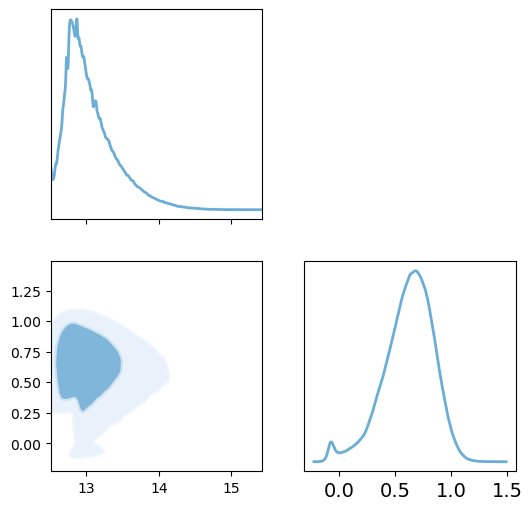

In [15]:
import arviz as az
fig, axar = plot_samples(np.array([prop_truth_all[:,0], np.log10(prop_truth_all[:,-1]) ]).T, plt.cm.Blues, cols=[0, 1])



In [ ]:
axar[1,0].plot(np.log10(prop_truth_all[:,0]), np.log10(c200c_colossus), 'o', alpha=0.1)
plt.show()


In [ ]:
rockstar[:,header.index('Rvir')]/rockstar[:,header.index('Rs')]


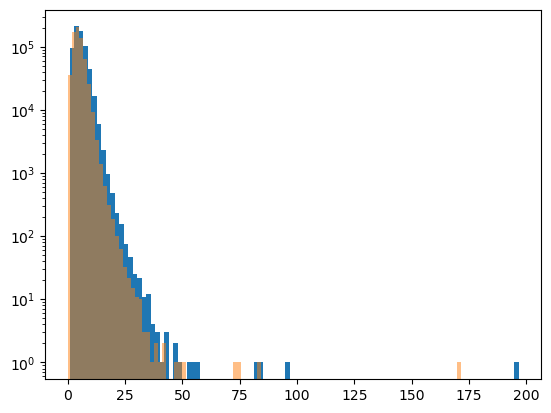

In [49]:
# header
pl.figure()
_ = pl.hist(rockstar[:,header.index('Rvir')]/rockstar[:,header.index('Rs')], bins=100)
_ = pl.hist(conc_sim, bins=100, alpha=0.5)
pl.yscale('log')


In [41]:
# pl.figure()
# _ = pl.hist(prop_truth_all[:,0], bins=100, histtype='step', lw=2, color='k')
# pl.yscale('log')
Rhalo

array([388.63282165, 374.40093907, 406.12217636, ..., 633.98230977,
       346.03238769, 329.91436025])

In [42]:
Rs

array([108.708,  65.565,  57.39 , ..., 451.869,  88.187, 147.914])

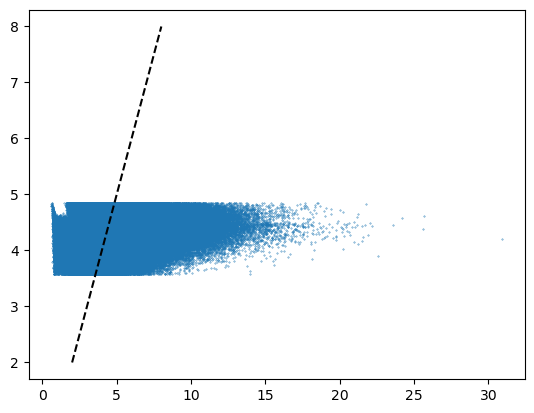

In [50]:
pl.figure()
pl.scatter(prop_truth_all[:,-1], c200c_colossus, s=0.1)
pl.plot([2, 8], [2, 8], 'k--')


In [ ]:
n

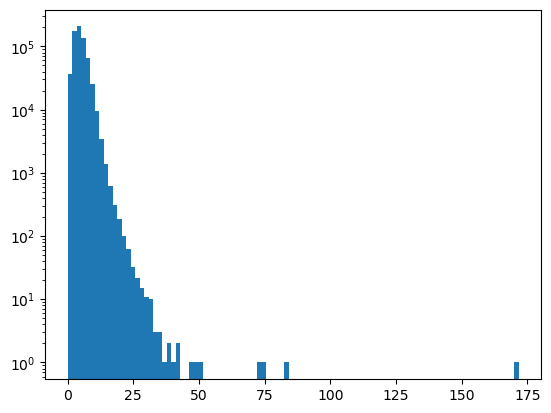

In [ ]:
# conc_sim
pl.figure()
_ = pl.hist(conc_sim, bins=100)
pl.yscale('log')




In [7]:
import matplotlib.pyplot as pl
%matplotlib inline


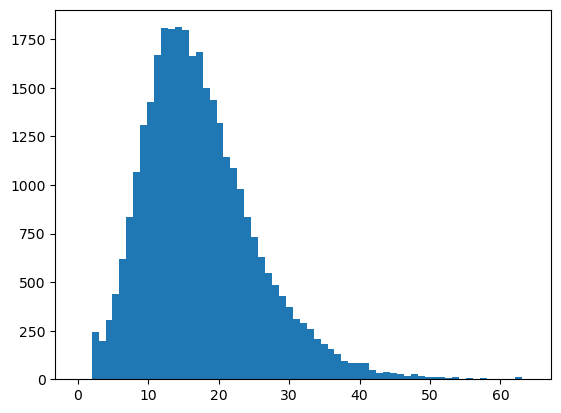

In [11]:
# df.keys()
# df['dmo_fields_all'].shape
# story_full.shape
pl.figure()
_ = pl.hist(story_full[:,8], bins=65, range=(0,64))



In [20]:
Om = 0.3
Ol = 0.7
z = 0.5
Hz = 100.0 * np.sqrt(Om * (1. + z)**3 + Ol)
rsd_factor = (1. + z) / Hz
0.5/rsd_factor


43.620841094341344

In [3]:
# if int(np.sum(Nhalos_truth)) > Ntot_sel_final:
#     print(isim, np.round(int(np.sum(Nhalos_truth))/Ntot_sel_final, 3))
# story_full.shape
Nhalos_truth_rs.shape


(32, 32, 32, 64, 64, 64)

In [1]:
import os
import sys
import numpy as np
import pickle as pk
import torch
import Pk_library as PKL
import MAS_library as MASL
# import galactic_wavelets as gw
from tqdm import tqdm
import redshift_space_library as RSL




In [6]:
dfp = np.loadtxt('/mnt/home/spandey/ceph/CHARM/notebooks/testing_notebooks/latin_hypercube_params.txt')
# dfp.shape
Om0, sig8 = dfp[:, 0], dfp[:, -1]
np.argmax(Om0)



1154

In [22]:
isfid = False

In [26]:
sdir = '/mnt/home/spandey/ceph/Quijote/halo_gotham_data/LH'
snapnum_hres = 73
# savefname_gals = f'{sdir}/halo_props_ng32/halo_props_snap_{snapnum_hres}_grid_{grid_sbox}_isim_{isim}_nrandsubsel_{nrand_sel_box}_nvocab{nvocab}_spacetoken_{add_space_token}_xMvc_{Mstar_cut}.pkl'
LH_cosmo_val_file='/mnt/home/spandey/ceph/Quijote/latin_hypercube_params.txt'
snapnum_hres_dict = {90:4, 73:3, 61:2}
snapnums_to_z_dict = {90:0.0, 73:0.5, 61:1.0}
redshift = snapnums_to_z_dict[snapnum_hres]
if isfid:
    cosmo_val_all = np.array([0.3175, 0.049, 0.6711, 0.9624, 0.834])
else:
    cosmo_val_all = np.loadtxt(LH_cosmo_val_file)[isim]

Om0 = cosmo_val_all[0]
Ob0 = cosmo_val_all[1]
h0 = cosmo_val_all[2]
ns = cosmo_val_all[3]
sigma8 = cosmo_val_all[4]
params = {'flat': True, 'H0': h0*100, 'Om0': Om0, 'Ob0': Ob0, 'sigma8': sigma8, 'ns': ns}
cosmo = cosmology.setCosmology('myCosmo', **params)

snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/latin_hypercube_HR'
verbose = False   #print information on progress
snapdir = snap_dir_base + '/' + str(isim)  #folder hosting the catalogue
rockstar = np.loadtxt(snapdir + '/out_' + str(snapnum_hres_dict[snapnum_hres]) + '_pid.list')
with open(snapdir + '/out_' + str(snapnum) + '_pid.list', 'r') as f:
    lines = f.readlines()
header = lines[0].split()
# get the properties of the halos
pos_h_truth = rockstar[:,header.index('X'):header.index('Z')+1]
index_M = header.index('M200c')                    
mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h
lgMass_truth = np.log10(mass_truth).astype(np.float32)
vel_h_truth = rockstar[:,header.index('VX'):header.index('VZ')+1]
Rhalo = (1+redshift)*mass_so.M_to_R(mass_truth, redshift, '200c')   
Rs = rockstar[:,header.index('Rs')]  
conc_sim = Rhalo/Rs
pid = rockstar[:,-1]
prop_truth_all = np.stack((lgMass_truth, vel_h_truth[:,0], vel_h_truth[:,1], vel_h_truth[:,2], conc_sim)).T
indsel = np.where((pid == -1) & (lgMass_truth > Mstar_cut))[0]
prop_truth_all = prop_truth_all[indsel,:]
pos_h_truth = pos_h_truth[indsel,:]



/tmp/ipykernel_944377/887899849.py:32: RuntimeWarning: divide by zero encountered in log10
  lgMass_truth = np.log10(mass_truth).astype(np.float32)


NameError: name 'Mstar_cut' is not defined

In [29]:
prop_truth_all.shape, np.where((pid == -1) & (lgMass_truth > 12.5))[0].shape, np.where((lgMass_truth > 12.5))[0].shape



((941217, 5), (878455,), (939015,))

In [ ]:
len(np.where(rockstar[:,-1] == -1)[0])/len(rockstar)


0.9355972108451079

In [8]:
grid_tot = 32
BoxSize = 1000.
Nhalos_truth = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
MASL.NGP(np.float32(pos_h_truth), Nhalos_truth, BoxSize)
# indsel = np.where(Nhalos_truth < 60)
np.sum(np.clip(Nhalos_truth, 0, 60))/np.sum(Nhalos_truth)
# Nhalos_truth_rs = np.reshape(Nhalos_truth, (grid, grid_sbox, grid, grid_sbox, grid, grid_sbox))
# Nhalos_truth_rs = mat_reshape(Nhalos_truth, grid, grid_sbox)

# nMax_points = int(np.amax(Nhalos_truth_rs))


0.9945539

In [9]:
import numpy as np
rng = np.random.default_rng(12345)



In [10]:
rng.choice(np.arange(0, 10), 5, replace=False)


array([4, 1, 9, 6, 2])

In [11]:
import matplotlib.pyplot as pl
%matplotlib inline


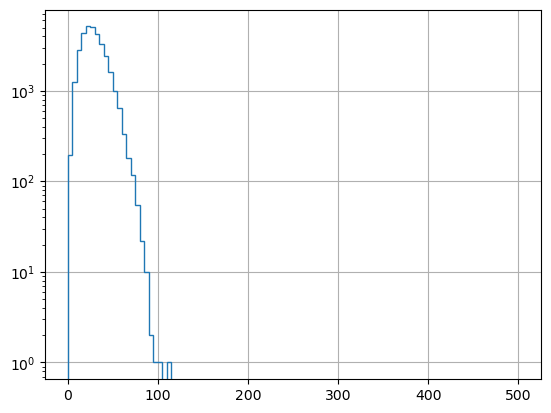

In [12]:
pl.figure()
_ = pl.hist(Nhalos_truth.flatten(), bins=100, histtype='step', range=(0, 500))
pl.yscale('log')
pl.grid()


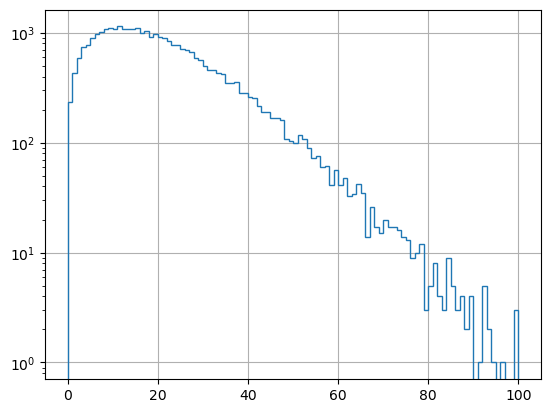

In [20]:
pl.figure()
_ = pl.hist(Nhalos_truth.flatten(), bins=100, histtype='step', range=(0, 100))
pl.yscale('log')
pl.grid()


In [26]:
import numpy as np
import sys,os
import MAS_library as MASL
import pickle as pk
import h5py as h5
# from ngp_funcs import NGP_xyz_prop 
import skimage.measure as skmeasure


%load_ext Cython


In [27]:
%%cython
cimport numpy as np
cpdef void NGP_xyz_prop(np.float32_t[:,:] pos, np.float32_t[:, :] prop, np.float32_t[:,:,:,:,:] gridM, float BoxSize):

    cdef int axis,dims,coord,nMmax,jM, coord_prop
    cdef long i,particles
    cdef float inv_cell_size
    cdef float pos0, pos1, pos2
    cdef int index[3]
    cdef int tobreak

    # find number of particles, the inverse of the cell size and dims
    particles = pos.shape[0];  coord = pos.shape[1];  dims = gridM.shape[0]; nMmax = gridM.shape[3]
    coord_prop = prop.shape[1]
    inv_cell_size = dims/BoxSize

    # when computing things in 2D, use the index[2]=0 plane
    for i in range(3):  index[i] = 0

    # do a loop over all particles
    for i in range(particles):
        for axis in range(coord):
            index[axis] = <int>(pos[i,axis]*inv_cell_size + 0.5)
            if axis == 0:
                pos0 = pos[i,axis] - index[axis]*BoxSize/dims
                
            if axis == 1:
                pos1 = pos[i,axis] - index[axis]*BoxSize/dims
                
            if axis == 2:
                pos2 = pos[i,axis] - index[axis]*BoxSize/dims
                
            index[axis] = (index[axis]+dims)%dims
        for jM in range(nMmax):
            if (gridM[index[0],index[1],index[2], jM, 0] == 0) and (gridM[index[0],index[1],index[2], jM, 1] == 0) and (gridM[index[0],index[1],index[2], jM, 2] == 0) and (gridM[index[0],index[1],index[2], jM, 3] == 0) and (gridM[index[0],index[1],index[2], jM, 4] == 0) and (gridM[index[0],index[1],index[2], jM, 5] == 0):
                gridM[index[0],index[1],index[2], jM, 0] = pos0
                gridM[index[0],index[1],index[2], jM, 1] = pos1
                gridM[index[0],index[1],index[2], jM, 2] = pos2
                for k in range(coord_prop):
                    gridM[index[0],index[1],index[2], jM, 3+k] = prop[i,k]
                break
            else:
                pass

                        


In file included from /mnt/home/spandey/miniconda3/envs/nbodykit/lib/python3.8/site-packages/numpy/core/include/numpy/ndarraytypes.h:1960,
                 from /mnt/home/spandey/miniconda3/envs/nbodykit/lib/python3.8/site-packages/numpy/core/include/numpy/ndarrayobject.h:12,
                 from /mnt/home/spandey/miniconda3/envs/nbodykit/lib/python3.8/site-packages/numpy/core/include/numpy/arrayobject.h:5,
                 from /dev/shm/.cache-spandey/ipython/cython/_cython_magic_3bb0286f679f3875b007c12837480e06.c:773:
/mnt/home/spandey/miniconda3/envs/nbodykit/lib/python3.8/site-packages/numpy/core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~
/dev/shm/.cache-spandey/ipython/cython/_cython_magic_3bb0286f679f3875b007c12837480e06.c: In function '__pyx_pw_46_cython_magic_3bb0286f679

In [ ]:
from nbodykit.source.catalog.file import BigFileCatalog
import nbodykit.lab as nb
import MAS_library as MASL
import pickle as pk
import numpy as np
import sys,os

def mat_reshape(mat, grid1, grid2):
    '''
    Reshape input mat into (grid1, grid1, grid1, grid2, grid2, grid2) shape
    '''
    if len(mat.shape) == 3:
        mat_rs = np.reshape(mat, (grid1, grid2, grid1, grid2, grid1, grid2))
    else:
        mat_rs = np.reshape(mat, (grid1, grid2, grid1, grid2, grid1, grid2, *mat.shape[3:]))

    mat_rs = np.moveaxis(mat_rs, 1, 2)
    mat_rs = np.moveaxis(mat_rs, 4, 3)
    mat_rs = np.moveaxis(mat_rs, 3, 2)
    return mat_rs


def get_padded_mat(Npart, n_pad, grid_sbox, grid):
    Npart_pad = np.pad(Npart, n_pad, 'wrap')

    Npart_pad1 = np.zeros((grid, grid, grid, grid_sbox + 2*n_pad, grid_sbox + 2*n_pad, grid_sbox + 2*n_pad))
    fac = (grid_sbox + 2*n_pad)//grid_sbox    
    Npart_pad1_reduce = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox))    
    xstart, ystart, zstart = n_pad, n_pad, n_pad
    for jx in range(grid):
        for jy in range(grid):
            for jz in range(grid):
                Npart_pad1[jx, jy, jz] = Npart_pad[xstart + jx * grid_sbox - n_pad:xstart + (jx + 1) * grid_sbox + n_pad,
                                                        ystart + jy * grid_sbox - n_pad:ystart + (jy + 1) * grid_sbox + n_pad,
                                                        zstart + jz * grid_sbox - n_pad:zstart + (jz + 1) * grid_sbox + n_pad]

                Npart_pad1_reduce[jx, jy, jz] = skmeasure.block_reduce(Npart_pad1[jx, jy, jz], (fac, fac, fac), np.mean)
    return Npart_pad1_reduce, Npart_pad1

def process_LH_sim(isim_fid, grid_sbox = 32):
    # nrand_sel_box = 128
    nrand_sel_box = 128
    norm_delta = 100
    norm_vel = 1000
    BoxSize = 1000.
    grid = 8

    MAS_type = 'CIC'
    grid_tot = grid_sbox * grid
    # snapnums = [90, 84, 78, 70, 60]
    snapnums = [90, 73, 61]    
    # snapnums = [73]    
    snapnums_to_z_dict = {90:0.0, 73:0.5, 61:1.0}
    # snapnums_to_z_dict = {73:0.5}


    sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH/DMO_fields'
    savefname_dmo_fields = f'{sdir}/DMO_fields_grid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_MAS_{MAS_type}_nsnaps_{len(snapnums)}.pkl'


    for js, snapnum in enumerate(snapnums):
        z_snap = snapnums_to_z_dict[snapnum]
        a_snap = 1/(1 + z_snap)
        
        root = '/mnt/home/spandey/ceph/fastpm-shivam/LH_HR/'
        fname =  f'{root}/{isim_fid}/fastpm_B2_' + str('%.4f' % a_snap) 

        np.random.seed(0)
        df = nb.BigFileCatalog(fname, dataset='1')        
        pos_m_truth = np.array(df['Position'], dtype=np.float64)
        vel_m_truth = np.array(df['Velocity'], dtype=np.float64)  

        rho_bar = len(pos_m_truth)/(BoxSize**3)
        vol_vox = (BoxSize/grid_tot)**3
        N_bar_vox = rho_bar * vol_vox

        Npart = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
        MASL.MA(np.float32(pos_m_truth), Npart, BoxSize, MAS_type, verbose=False)

        Npart /= N_bar_vox
        Npart /= norm_delta

        Npart_rs = mat_reshape(Npart, grid, grid_sbox)

        npad1 = grid_sbox
        Npart_pad1_rs, _ = get_padded_mat(Npart, int(npad1), grid_sbox, grid)

        npad2 = 2*grid_sbox
        Npart_pad2_rs, _ = get_padded_mat(Npart, int(npad2), grid_sbox, grid)

        vel_m_part = np.float32(np.zeros((grid_tot, grid_tot, grid_tot, 3)))

        Npart_cic = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
        MASL.MA(np.float32(pos_m_truth), Npart_cic, BoxSize, 'CIC', verbose=False)

        


        for jc in range(3):
            mom_jc = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
            MASL.MA(np.float32(pos_m_truth), mom_jc, BoxSize, 'CIC', verbose=False, W=vel_m_truth[:,jc].astype(np.float32))
            vel_m_jc = mom_jc/Npart_cic
            vel_m_jc[~np.isfinite(vel_m_jc)] = 0.0
            
            # vx_all_3D_interp_l = RegularGridInterpolator((xarray, yarray, zarray), vel_m_jc, bounds_error=False, fill_value=None)


            vel_m_part[..., jc] = vel_m_jc/norm_vel

        vel_m_part_rs = mat_reshape(vel_m_part, grid, grid_sbox)

        dmo_fields_all_snap = np.concatenate((Npart_rs[...,None], Npart_pad1_rs[...,None], Npart_pad2_rs[...,None], vel_m_part_rs), axis=-1)

        if js == 0:
            dmo_fields_all = dmo_fields_all_snap
        else:
            dmo_fields_all = np.concatenate((dmo_fields_all, dmo_fields_all_snap), axis=-1)


    dmo_fields_all_rs = dmo_fields_all.reshape((grid**3, *dmo_fields_all.shape[3:]))

    if nrand_sel_box < grid**3:
        import numpy as np
        np.random.seed(0)
        dmo_fields_all_rs_z0 = dmo_fields_all_rs[:, ..., 0]
        Npart_sum = np.sum(dmo_fields_all_rs_z0, axis=(1, 2, 3))

        npart_min = np.percentile(Npart_sum, 2.0)
        npart_max = np.percentile(Npart_sum, 98.0)
        hist, bins_edges = np.histogram(np.clip(Npart_sum, npart_min, npart_max) , bins=16)
        bins_edges[0] = 0.0
        bins_edges[-1] = bins_edges[-1]*100
        nsel_per_jb = nrand_sel_box//len(hist)

        indsel_all = []
        for jbd in range(len(bins_edges)-1):
            b1 = bins_edges[jbd]
            b2 = bins_edges[jbd + 1]
            indsel = np.where((Npart_sum >= b1) & (Npart_sum < b2))[0]
            if len(indsel) < nsel_per_jb:
                ind_in_jb = indsel
            else:
                ind_in_jb = np.random.choice(indsel, nsel_per_jb, replace=False)
            indsel_all.append(ind_in_jb)

        indsel_all = np.concatenate(indsel_all)

        if len(indsel_all) < nrand_sel_box:
            nmore_to_sel = nrand_sel_box - len(indsel_all)
            ind_to_sel_remaining = np.setdiff1d(np.arange(grid**3), indsel_all)
            indsel_remaining = np.random.choice(ind_to_sel_remaining, nmore_to_sel, replace=False)
            indsel_all = np.concatenate((indsel_all, indsel_remaining))

        Npart_sum_sel = Npart_sum[indsel_all]
        rand_sel = np.random.permutation(indsel_all)
    else:
        import numpy as np
        rand_sel = np.arange(grid**3)
    
    saved = {'dmo_fields_all': dmo_fields_all_rs.astype(np.float32)[rand_sel, ...],
             'snapnums': snapnums,
            'rand_sel': rand_sel,
            'norm_delta': norm_delta,
            'norm_vel': norm_vel,
             'grid_sbox':grid_sbox,
             'grid':grid,
             'MAS_type':MAS_type         
            }
    pk.dump(saved, open(savefname_dmo_fields, 'wb'))
    


In [47]:
from nbodykit.source.catalog.file import BigFileCatalog
import nbodykit.lab as nb
import skimage.measure as skmeasure
import ast

isim_fid = 3
grid_sbox = 16
nrand_sel_box = 1024
norm_delta = 50
norm_vel = 2000
BoxSize = 1000.
grid = 16

MAS_type = 'CIC'
grid_tot = grid_sbox * grid
# snapnums = [90, 84, 78, 70, 60]
# snapnums = [90, 73, 61]    
snapnums = [73, 61]    
# snapnums = [73]    
snapnums_to_z_dict = {90:0.0, 73:0.5, 61:1.0}
# snapnums_to_z_dict = {73:0.5}


sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH/DMO_fields'
savefname_dmo_fields = f'{sdir}/DMO_fields_grid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_MAS_{MAS_type}_nsnaps_{len(snapnums)}.pkl'


for js, snapnum in enumerate(snapnums):
    z_snap = snapnums_to_z_dict[snapnum]
    a_snap = 1/(1 + z_snap)
    
    root = '/mnt/home/spandey/ceph/fastpm-shivam/LH_HR/'
    fname =  f'{root}/{isim_fid}/fastpm_B2_' + str('%.4f' % a_snap) 

    np.random.seed(0)
    df = nb.BigFileCatalog(fname, dataset='1')        
    pos_m_truth = np.array(df['Position'], dtype=np.float64)
    vel_m_truth = np.array(df['Velocity'], dtype=np.float64)  

    rho_bar = len(pos_m_truth)/(BoxSize**3)
    vol_vox = (BoxSize/grid_tot)**3
    N_bar_vox = rho_bar * vol_vox

    Npart = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
    MASL.MA(np.float32(pos_m_truth), Npart, BoxSize, MAS_type, verbose=False)

    Npart /= N_bar_vox
    Npart /= norm_delta

    Npart_rs = mat_reshape(Npart, grid, grid_sbox)

    npad1 = grid_sbox
    Npart_pad1_rs, _ = get_padded_mat(Npart, int(npad1), grid_sbox, grid)

    npad2 = 2*grid_sbox
    Npart_pad2_rs, _ = get_padded_mat(Npart, int(npad2), grid_sbox, grid)

    vel_m_part = np.float32(np.zeros((grid_tot, grid_tot, grid_tot, 3)))

    Npart_cic = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
    MASL.MA(np.float32(pos_m_truth), Npart_cic, BoxSize, 'CIC', verbose=False)

    


    for jc in range(3):
        mom_jc = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
        MASL.MA(np.float32(pos_m_truth), mom_jc, BoxSize, 'CIC', verbose=False, W=vel_m_truth[:,jc].astype(np.float32))
        vel_m_jc = mom_jc/Npart_cic
        vel_m_jc[~np.isfinite(vel_m_jc)] = 0.0
        
        # vx_all_3D_interp_l = RegularGridInterpolator((xarray, yarray, zarray), vel_m_jc, bounds_error=False, fill_value=None)


        vel_m_part[..., jc] = vel_m_jc/norm_vel

    vel_m_part_rs = mat_reshape(vel_m_part, grid, grid_sbox)

    dmo_fields_all_snap = np.concatenate((Npart_rs[...,None], Npart_pad1_rs[...,None], Npart_pad2_rs[...,None], vel_m_part_rs), axis=-1)

    if js == 0:
        dmo_fields_all = dmo_fields_all_snap
    else:
        dmo_fields_all = np.concatenate((dmo_fields_all, dmo_fields_all_snap), axis=-1)


dmo_fields_all_rs = dmo_fields_all.reshape((grid**3, *dmo_fields_all.shape[3:]))

if nrand_sel_box < grid**3:
    import numpy as np
    np.random.seed(0)
    dmo_fields_all_rs_z0 = dmo_fields_all_rs[:, ..., 0]
    Npart_sum = np.sum(dmo_fields_all_rs_z0, axis=(1, 2, 3))

    npart_min = np.percentile(Npart_sum, 2.0)
    npart_max = np.percentile(Npart_sum, 98.0)
    hist, bins_edges = np.histogram(np.clip(Npart_sum, npart_min, npart_max) , bins=16)
    bins_edges[0] = 0.0
    bins_edges[-1] = bins_edges[-1]*100
    nsel_per_jb = nrand_sel_box//len(hist)

    indsel_all = []
    for jbd in range(len(bins_edges)-1):
        b1 = bins_edges[jbd]
        b2 = bins_edges[jbd + 1]
        indsel = np.where((Npart_sum >= b1) & (Npart_sum < b2))[0]
        if len(indsel) < nsel_per_jb:
            ind_in_jb = indsel
        else:
            ind_in_jb = np.random.choice(indsel, nsel_per_jb, replace=False)
        indsel_all.append(ind_in_jb)

    indsel_all = np.concatenate(indsel_all)

    if len(indsel_all) < nrand_sel_box:
        nmore_to_sel = nrand_sel_box - len(indsel_all)
        ind_to_sel_remaining = np.setdiff1d(np.arange(grid**3), indsel_all)
        indsel_remaining = np.random.choice(ind_to_sel_remaining, nmore_to_sel, replace=False)
        indsel_all = np.concatenate((indsel_all, indsel_remaining))

    Npart_sum_sel = Npart_sum[indsel_all]
    rand_sel = np.random.permutation(indsel_all)
else:
    import numpy as np
    rand_sel = np.arange(grid**3)




/mnt/home/spandey/miniconda3/envs/nbodykit/lib/python3.8/site-packages/bigfile/__init__.py:358: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  return pyxbigfile.Dataset.__init__(self, file, dtype=dtype, size=size)
/tmp/ipykernel_859014/2490075586.py:69: RuntimeWarning: invalid value encountered in true_divide
  vel_m_jc = mom_jc/Npart_cic


In [48]:
rand_sel



array([1788,  487, 1681, ...,  780, 3697, 3048])

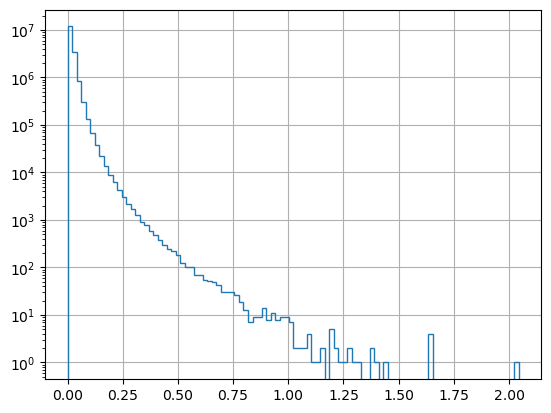

In [56]:
pl.figure()
_ = pl.hist(dmo_fields_all_rs[...,6].flatten(), bins=100, histtype='step')
pl.yscale('log')
pl.grid()




In [87]:
dmo_fields_all_rs.shape


(512, 32, 32, 32, 18)

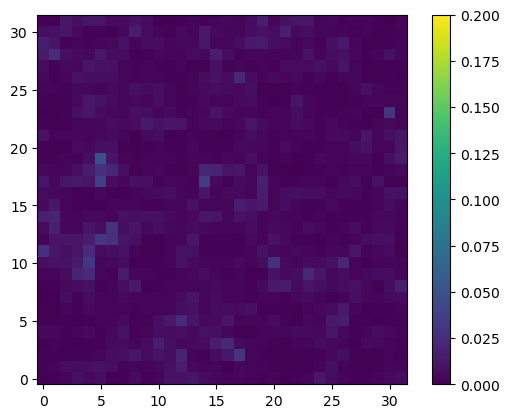

In [100]:
# rand_sel
pl.figure()
pl.imshow(dmo_fields_all_rs[0, :, :, 16, 1], origin='lower', vmin=0, vmax=0.2)
pl.colorbar()


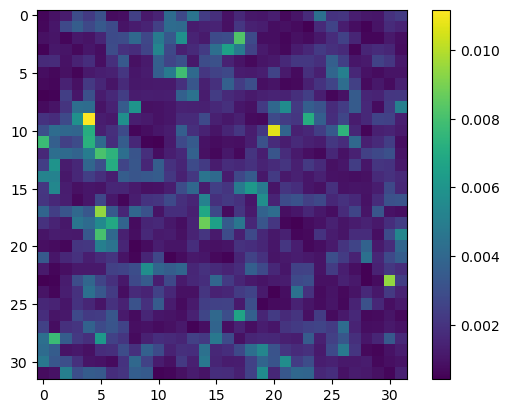

In [95]:
# rand_sel
pl.figure()
pl.imshow(dmo_fields_all_rs[0, :, :, 16, 7])
pl.colorbar()

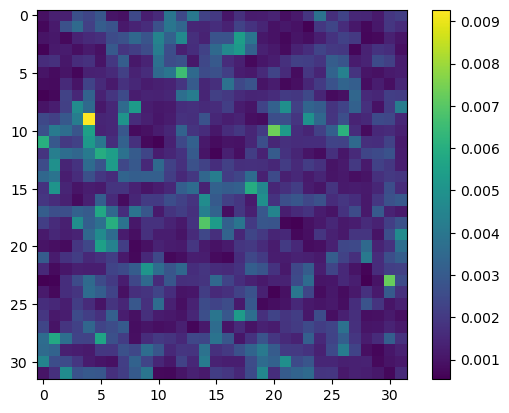

In [96]:
# rand_sel
pl.figure()
pl.imshow(dmo_fields_all_rs[0, :, :, 16, 13])
pl.colorbar()

In [38]:
# indsel_all
Npart_sum_sel = Npart_sum[indsel_all]
indsel_rand = np.random.choice(np.arange(grid**3), nrand_sel_box, replace=False)
Npart_sum_rand = Npart_sum[indsel_rand]

In [39]:
import matplotlib.pyplot as pl
%matplotlib inline


(0.0, 0.06457375539035323)

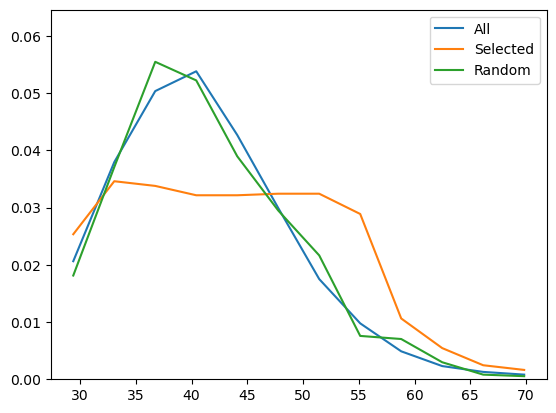

In [41]:


hist_orig, bins_edges_top = np.histogram(Npart_sum , bins = 12, range=(npart_min, 1.2*npart_max), density=True)
hist_sel, bins_edges_top = np.histogram(Npart_sum_sel, bins = 12, range=(npart_min, 1.2*npart_max), density=True)
hist_rand, bins_edges_top = np.histogram(Npart_sum_rand, bins = 12, range=(npart_min, 1.2*npart_max), density=True)

bins_cen_top = 0.5*(bins_edges_top[1:] + bins_edges_top[:-1])

pl.figure()
# _ = pl.hist(Npart_sum , bins=8, histtype='step')
# _ = pl.hist(Npart_sum[indsel_all] , bins=8, histtype='step')
pl.plot(bins_cen_top, hist_orig, label='All')
pl.plot(bins_cen_top, hist_sel, label='Selected')
pl.plot(bins_cen_top, hist_rand, label='Random')
pl.legend()
pl.ylim(0, 1.2*np.amax(hist_orig))
# pl.xlim(0, 100)
# pl.axvline(npart_min, color='k', ls='--')
# pl.axvline(npart_max, color='k', ls='--')
# pl.axvline(npart_min + 2*delta_npart, color='k', ls='--')
# pl.axvline(npart_min + 3*delta_npart, color='k', ls='--')
# pl.yscale('log')


In [ ]:
# # Npart_rs.shape
# # vel_m_part_rs.shape
# # vel_m_jc.shape
# from scipy.interpolate import RegularGridInterpolator
# xall = (np.linspace(0, BoxSize, grid_tot + 1))
# xarray = 0.5 * (xall[1:] + xall[:-1])
# yarray = np.copy(xarray)
# zarray = np.copy(xarray)

# vx_all_3D_interp_l = RegularGridInterpolator((xarray, yarray, zarray), vel_m_jc/norm_vel, bounds_error=False, fill_value=None)



In [19]:
# # indsel
indsel = np.where(vel_m_jc == 0)
print(indsel, len(indsel[0]))
# xsel = xarray[indsel[0]]
# ysel = yarray[indsel[1]]
# zsel = zarray[indsel[2]]
# pos_sel = np.stack((xsel, ysel, zsel), axis=-1)


(array([  0,   0,   0, ..., 383, 383, 383]), array([  0,   1,   1, ..., 381, 382, 383]), array([313, 286, 287, ..., 351,  52,  49])) 392373


In [ ]:
# indsel = np.where(vel_m_jc == 0)
# vx_eval_interp_l = vx_all_3D_interp_l(pos_sel)


In [ ]:
# vx_eval_interp_l


array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
# vel_old = (vel_m_jc/norm_vel)



In [ ]:
# from scipy.interpolate import griddata

# data = np.copy(vel_m_jc/norm_vel)
# mask = data == 0
# x, y, z = np.mgrid[:data.shape[0], :data.shape[1], :data.shape[2]]

# # Get known (non-zero) points and their values
# points = np.array((x[~mask], y[~mask], z[~mask])).T
# values = data[~mask]

# # Interpolate missing values
# interpolated = griddata(points, values, (x[mask], y[mask], z[mask]), method='linear')

# # Fill the masked points with interpolated values
# data[mask] = interpolated
# vel_new = data


In [ ]:
# vel_new[indsel] = vx_eval_interp_l


In [ ]:
# # Npart_rs.shape
# import matplotlib.pyplot as pl
# %matplotlib inline



In [10]:
# pl.figure()
# _ = pl.imshow(Npart_cic[100:200,100:200,10], origin='lower')
# pl.colorbar()


In [11]:
# pl.figure()
# _ = pl.imshow(vel_old[100:200,100:200,10], origin='lower')
# pl.colorbar()


In [12]:
# pl.figure()
# _ = pl.imshow(vel_new[100:200,100:200,10], origin='lower')



In [13]:
# pl.figure()
# _ = pl.imshow(vel_m_part_rs[10,10,10,:,:,:,0][:,:,4], origin='lower')
# pl.colorbar()


In [14]:
# np.sum(Npart_rs, axis=(-1, -2, -3)).shape

Npart_sum = np.sort(np.sum(Npart_rs, axis=(-1, -2, -3)).flatten())


In [15]:
npart_min = np.percentile(Npart_sum, 1.0)
npart_max = np.percentile(Npart_sum, 99.0)
# nsplits = 4
# delta_npart = (npart_max - npart_min)/nsplits


# splits = np.linspace(npart_min, npart_max, 3, endpoint=False)


In [ ]:
# jd = 3
# len(np.where((Npart_sum > npart_min + jd*delta_npart) & (Npart_sum < npart_min + (jd+1)*delta_npart))[0])



176

In [36]:
hist, bins_edges = np.histogram(np.clip(Npart_sum, npart_min, npart_max) , bins=8)
# hist, bins_edges = np.histogram(Npart_sum , bins=12)
bins_edges[0] = 0.0
bins_edges[-1] = bins_edges[-1]*100


In [37]:
# np.sum(hist)
hist




array([ 31,  97, 124, 117,  88,  37,  10,   8])

In [22]:
# pdf = 1/hist
# pdf
# pdf_norm = pdf/np.sum(pdf)
# cdf = np.cumsum(pdf_norm)
# hist
ntotal = 512
nsamp_per_bin = ntotal//len(hist)
for jb in range(len(hist)):
    # print(jb, nsamp_per_bin, hist[jb])
    jbv_min = bins_edges[jb]
    jbv_max = bins_edges[jb+1]
    indsel = np.where((Npart_sum > jbv_min) & (Npart_sum < jbv_max))[0]



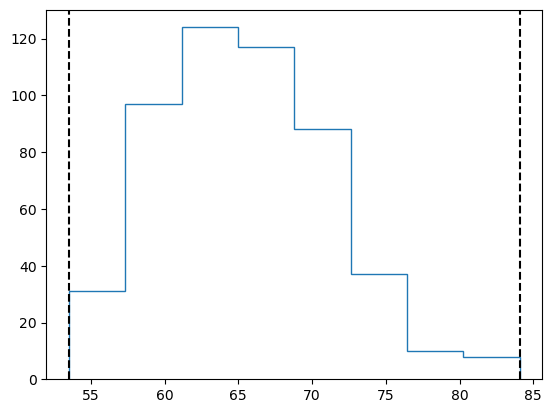

In [31]:
pl.figure()
_ = pl.hist(np.clip(Npart_sum, npart_min, npart_max) , bins=8, histtype='step')
# pl.axvline(np.percentile(Npart_sum, 25), color='k', ls='--')
# pl.axvline(np.percentile(Npart_sum, 50), color='k', ls='--')
# pl.axvline(np.percentile(Npart_sum, 75), color='k', ls='--')
pl.axvline(npart_min, color='k', ls='--')
pl.axvline(npart_max, color='k', ls='--')
# pl.axvline(npart_min + 2*delta_npart, color='k', ls='--')
# pl.axvline(npart_min + 3*delta_npart, color='k', ls='--')
# pl.yscale('log')
